Initial Shape: (541909, 8)
Cleaned Shape: (397884, 9)


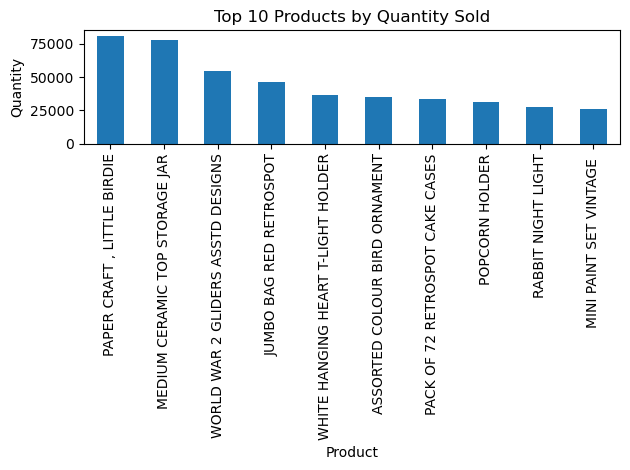

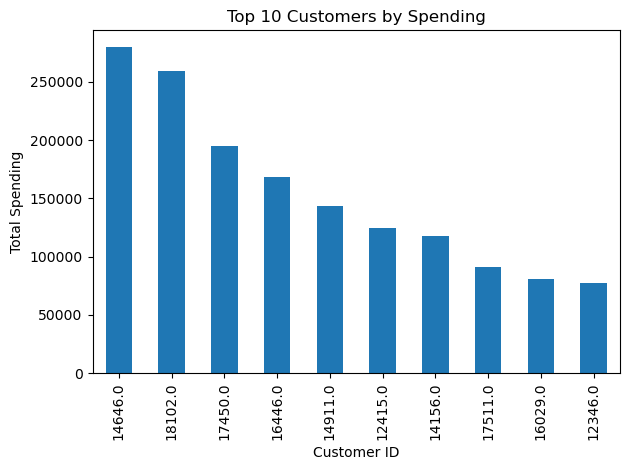

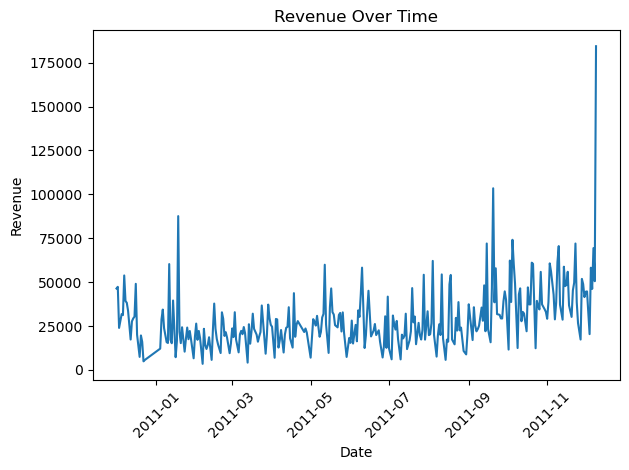

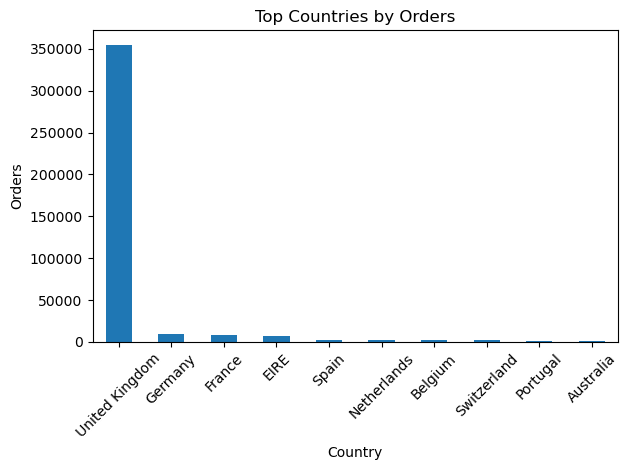

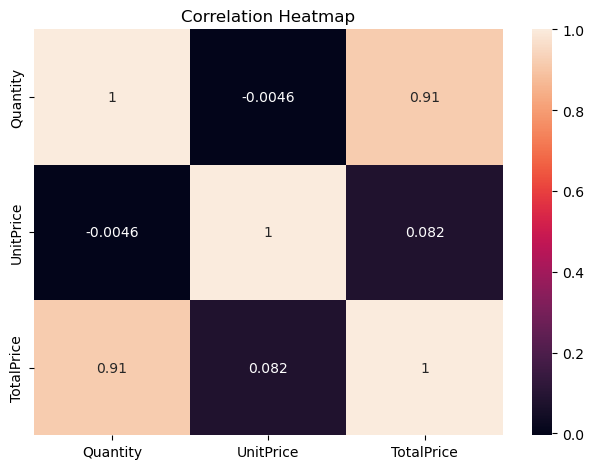


===== KEY INSIGHTS =====

Top Country: United Kingdom
Most Sold Product: PAPER CRAFT , LITTLE BIRDIE
Highest Revenue Product: PAPER CRAFT , LITTLE BIRDIE
Top Customer ID: 14646.0
Peak Sales Date: 2011-12-09
Total Revenue: 8911407.904


All outputs saved in: F:\OUTRIX Data\outputs


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================
# Create Output Folder
# =========================
output_folder = r"F:\OUTRIX Data\outputs"
os.makedirs(output_folder, exist_ok=True)

# =========================
# Load Dataset
# =========================
file_path = r"F:\OUTRIX Data\data.csv"
df = pd.read_csv(file_path, encoding='latin1')

print("Initial Shape:", df.shape)

# =========================
# Data Cleaning
# =========================
df.dropna(inplace=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Shape:", df.shape)

# Save cleaned dataset
cleaned_path = os.path.join(output_folder, "cleaned_data.csv")
df.to_csv(cleaned_path, index=False)

# =========================
# Customer Analysis
# =========================
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# =========================
# Product Analysis
# =========================
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

# =========================
# Time Analysis
# =========================
df['Date'] = df['InvoiceDate'].dt.date
daily_sales = df.groupby('Date')['TotalPrice'].sum()

# =========================
# VISUALIZATIONS (WITH SAVE)
# =========================

# 1. Top Products
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_products.png"))
plt.show()

# 2. Top Customers
plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_customers.png"))
plt.show()

# 3. Revenue Over Time
plt.figure()
daily_sales.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "revenue_over_time.png"))
plt.show()

# 4. Top Countries
plt.figure()
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_countries.png"))
plt.show()

# 5. Correlation Heatmap
plt.figure()
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"))
plt.show()

# =========================
# INSIGHTS (SAVE TO FILE)
# =========================
insights = f"""
Top Country: {df['Country'].value_counts().idxmax()}
Most Sold Product: {top_products.idxmax()}
Highest Revenue Product: {top_revenue_products.idxmax()}
Top Customer ID: {top_customers.idxmax()}
Peak Sales Date: {daily_sales.idxmax()}
Total Revenue: {df['TotalPrice'].sum()}
"""

print("\n===== KEY INSIGHTS =====")
print(insights)

# Save insights
with open(os.path.join(output_folder, "insights.txt"), "w") as f:
    f.write(insights)

print(f"\nAll outputs saved in: {output_folder}")